Epoch 0 | Loss: 1.0011
Epoch 500 | Loss: 0.9996
Epoch 1000 | Loss: 0.9994
Epoch 1500 | Loss: 0.9998
Epoch 2000 | Loss: 1.0000
Epoch 2500 | Loss: 0.9997


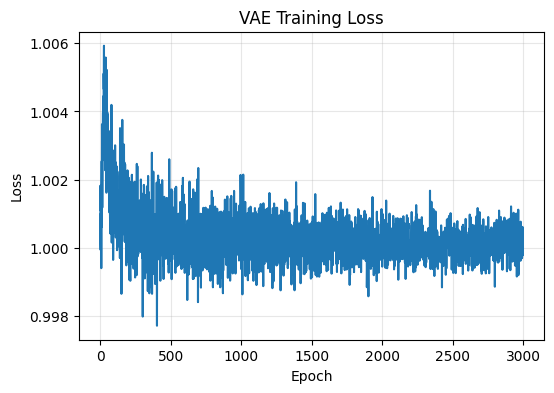

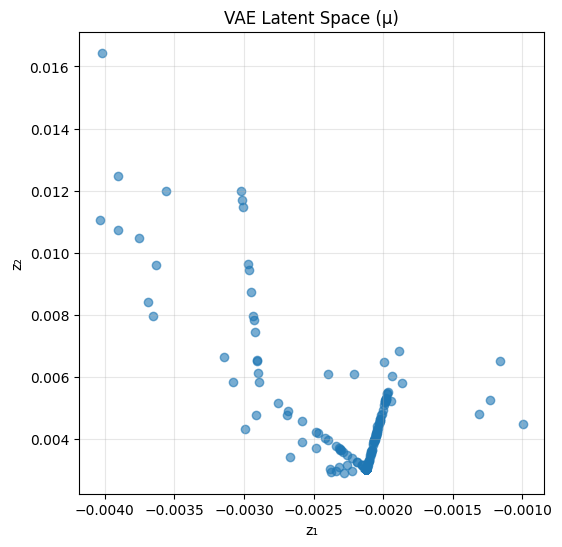

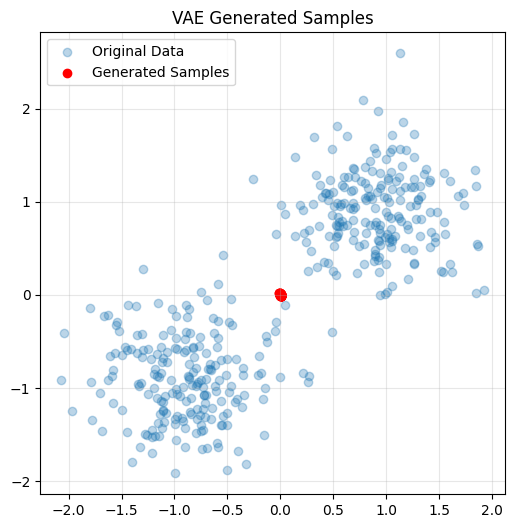

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. utility functions
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(float)

def mse(x, x_hat):
    return np.mean((x - x_hat) ** 2)

def init(shape):
    return np.random.randn(*shape) * 0.1

# 2. create toy dataset
np.random.seed(42)

N = 400
X1 = np.random.randn(N // 2, 2) + np.array([2, 2])
X2 = np.random.randn(N // 2, 2) + np.array([-2, -2])
X = np.vstack([X1, X2])

# normalize
X = (X - X.mean(axis=0)) / X.std(axis=0)

# 3. model dimensions
input_dim = 2
hidden_dim = 8
latent_dim = 2

lr = 0.01
epochs = 3000

# 4. Initialize Parameters
# Encoder
W1 = init((input_dim, hidden_dim))
b1 = np.zeros(hidden_dim)

W_mu = init((hidden_dim, latent_dim))
b_mu = np.zeros(latent_dim)

W_logvar = init((hidden_dim, latent_dim))
b_logvar = np.zeros(latent_dim)

# Decoder
W2 = init((latent_dim, hidden_dim))
b2 = np.zeros(hidden_dim)

W3 = init((hidden_dim, input_dim))
b3 = np.zeros(input_dim)

# 5. Training loop
losses = []

for epoch in range(epochs):

    # ----- Encoder -----
    h1 = relu(X @ W1 + b1)

    mu = h1 @ W_mu + b_mu
    logvar = h1 @ W_logvar + b_logvar
    std = np.exp(0.5 * logvar)

    eps = np.random.randn(*std.shape)
    z = mu + std * eps   # reparameterization trick

    # ----- Decoder -----
    h2 = relu(z @ W2 + b2)
    X_hat = h2 @ W3 + b3

    # ----- Loss -----
    recon_loss = mse(X, X_hat)
    kl_loss = np.mean(-0.5 * (1 + logvar - mu**2 - np.exp(logvar)))
    loss = recon_loss + kl_loss
    losses.append(loss)

    # ----- Backpropagation -----
    dX_hat = 2 * (X_hat - X) / len(X)

    dW3 = h2.T @ dX_hat
    db3 = dX_hat.sum(axis=0)

    dh2 = dX_hat @ W3.T * relu_grad(h2)
    dW2 = z.T @ dh2
    db2 = dh2.sum(axis=0)

    dz = dh2 @ W2.T

    dmu = dz
    dlogvar = dz * eps * std * 0.5 + 0.5 * (np.exp(logvar) - 1)

    dW_mu = h1.T @ dmu
    db_mu = dmu.sum(axis=0)

    dW_logvar = h1.T @ dlogvar
    db_logvar = dlogvar.sum(axis=0)

    dh1 = (dmu @ W_mu.T + dlogvar @ W_logvar.T) * relu_grad(h1)

    dW1 = X.T @ dh1
    db1 = dh1.sum(axis=0)

    # ----- Parameter Update -----
    for param, grad in zip(
        [W1, b1, W_mu, b_mu, W_logvar, b_logvar, W2, b2, W3, b3],
        [dW1, db1, dW_mu, db_mu, dW_logvar, db_logvar, dW2, db2, dW3, db3]
    ):
        param -= lr * grad

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f}")

# Visualizations
# 1. Plot Training Loss
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")
plt.grid(alpha=0.3)
plt.show()


# 2. Latent Space Visualization
plt.figure(figsize=(6,6))
plt.scatter(mu[:,0], mu[:,1], alpha=0.6)
plt.xlabel("z₁")
plt.ylabel("z₂")
plt.title("VAE Latent Space (μ)")
plt.grid(alpha=0.3)
plt.show()


# 3. Generate New Samples
z_new = np.random.randn(100, latent_dim)

h = relu(z_new @ W2 + b2)
X_new = h @ W3 + b3

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], alpha=0.3, label="Original Data")
plt.scatter(X_new[:,0], X_new[:,1], c="red", label="Generated Samples")
plt.legend()
plt.title("VAE Generated Samples")
plt.grid(alpha=0.3)
plt.show()